# RaksaDana - BMRI.JK Return-Based LSTM Modelling & Evaluation

Target utama notebook ini adalah `Next_Log_Return`, bukan raw scaled `Close`. Harga tetap dievaluasi dengan rekonstruksi `current_close * exp(predicted_return)`, sehingga model tidak dipaksa extrapolate level harga saat test melewati range train.


## Setup


In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.regularizers import l2
except Exception as exc:
    tf = None
    TF_IMPORT_ERROR = exc
else:
    TF_IMPORT_ERROR = None

warnings.filterwarnings('ignore')
%matplotlib inline

TICKER = 'BMRI.JK'
SAFE_TICKER = TICKER.replace('.', '_')
SEEDS = [42, 123, 7]
WINDOW_SIZE = 60
TEST_SIZE = 0.20
VAL_SIZE = 0.15

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name.lower() == 'notebook' else cwd
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'
FIGURE_DIR      = ROOT / 'outputs' / 'figures' / SAFE_TICKER
RETURN_REPORT_DIR = REPORT_DIR / 'return_model' / SAFE_TICKER
RETURN_MODEL_DIR = MODEL_DIR / 'return_model'
for _dir in [MODEL_DIR, REPORT_DIR, FIGURE_DIR, RETURN_REPORT_DIR, RETURN_MODEL_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

ACTUAL_COLOR = '#1565C0'
LSTM_COLOR = '#D32F2F'
RIDGE_COLOR = '#2E7D32'
MA5_COLOR = '#F57C00'
NAIVE_COLOR = '#6D6D6D'
MODEL_COLORS = {
    'Actual': ACTUAL_COLOR,
    'Naive': NAIVE_COLOR,
    'MA5': MA5_COLOR,
    'Ridge': RIDGE_COLOR,
    'LSTM': LSTM_COLOR,
}

print(f'Ticker        : {TICKER}')
print(f'ROOT          : {ROOT}')
print(f'FIGURE DIR    : {FIGURE_DIR}')
print(f'REPORT DIR    : {RETURN_REPORT_DIR}')
print(f'TensorFlow    : {tf.__version__ if tf is not None else "not available"}')
if TF_IMPORT_ERROR is not None:
    print(f'TensorFlow import error: {TF_IMPORT_ERROR}')


Ticker        : BMRI.JK
ROOT          : c:\Users\akbar\VSCode Project\RaksaDana
FIGURE DIR    : c:\Users\akbar\VSCode Project\RaksaDana\outputs\figures\BMRI_JK
REPORT DIR    : c:\Users\akbar\VSCode Project\RaksaDana\reports\return_model\BMRI_JK
TensorFlow    : 2.21.0


In [2]:
METRIC_FORMAT = {
    'Return_MAE': '{:.5f}',
    'Return_RMSE': '{:.5f}',
    'Price_MAE': '{:,.2f}',
    'Price_RMSE': '{:,.2f}',
    'Price_MAPE': '{:.3f}%',
    'Price_R2': '{:.4f}',
    'Direction_Accuracy': '{:.2f}%',
}

METRIC_COLUMNS = [
    'Ticker', 'Split', 'Model',
    'Return_MAE', 'Return_RMSE',
    'Price_MAE', 'Price_RMSE', 'Price_MAPE', 'Price_R2',
    'Direction_Accuracy',
]

def show_metrics(title, table):
    print('\n' + '=' * 90)
    print(title)
    print('=' * 90)
    display(
        table[METRIC_COLUMNS]
        .sort_values(['Split', 'Model'])
        .style
        .format(METRIC_FORMAT)
        .background_gradient(subset=['Return_RMSE', 'Price_RMSE', 'Price_MAPE'], cmap='RdYlGn_r')
        .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
    )


## Data


In [3]:
def load_featured(ticker):
    path = PROCESSED_DIR / f'{ticker.replace(".", "_")}_featured.csv'
    df = pd.read_csv(path, parse_dates=['Date'])
    return df.sort_values('Date').reset_index(drop=True)


def add_return_features(df):
    df = df.copy()
    df['Next_Log_Return'] = np.log(df['Close'].shift(-1) / df['Close'])
    df['Next_Close'] = df['Close'].shift(-1)
    df['Target_Date'] = df['Date'].shift(-1)
    df['Close_Log_Return_1'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Return_3'] = df['Close'].pct_change(3)
    df['Return_5'] = df['Close'].pct_change(5)
    df['Return_10'] = df['Close'].pct_change(10)
    df['Volatility_5'] = df['Close_Log_Return_1'].rolling(5).std()
    df['Volatility_10'] = df['Close_Log_Return_1'].rolling(10).std()
    df['Volatility_20'] = df['Close_Log_Return_1'].rolling(20).std()
    df['Volume_Change'] = df['Volume'].pct_change()
    df['Volume_Ratio_7'] = df['Volume'] / df['Volume_MA7']
    df['MACD_Hist'] = df['MACD'] - df['MACD_signal']
    df['BB_width_pct'] = df['BB_width'] / df['Close']

    feature_cols = [
        'Close_Log_Return_1', 'Daily_Return', 'Return_3', 'Return_5', 'Return_10',
        'Volatility_5', 'Volatility_10', 'Volatility_20', 'RSI',
        'MACD', 'MACD_signal', 'MACD_Hist', 'BB_width_pct',
        'Volume_Change', 'Volume_Ratio_7',
    ]
    needed = feature_cols + ['Next_Log_Return', 'Next_Close', 'Target_Date']
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=needed)
    return df.reset_index(drop=True), feature_cols

raw_df = load_featured(TICKER)
df, feature_cols = add_return_features(raw_df)
fundamental_snapshot = raw_df[['ROE', 'EPS', 'DY']].iloc[-1].to_dict()

print(f'Raw rows      : {len(raw_df):,}')
print(f'Model rows    : {len(df):,}')
print(f'Date range    : {df.Date.min().date()} -> {df.Date.max().date()}')
print(f'Feature count : {len(feature_cols)}')
print('Fundamental snapshot:', fundamental_snapshot)
df[['Date', 'Close', 'Next_Close', 'Next_Log_Return'] + feature_cols[:5]].head()


Raw rows      : 2,673
Model rows    : 2,584
Date range    : 2015-04-13 -> 2026-01-15
Feature count : 15
Fundamental snapshot: {'ROE': 0.21040002, 'EPS': 603.12, 'DY': 0.1135999999999999}


,Date,Close,Next_Close,Next_Log_Return,Close_Log_Return_1,Daily_Return,Return_3,Return_5,Return_10
0,2015-04-13,1762.027222,1732.781982,-0.016737,0.004158,0.004167,-0.002070,-0.010267,0.008368
1,2015-04-14,1732.781982,1762.027222,0.016737,-0.016737,-0.016597,-0.012500,-0.026694,-0.020661
2,2015-04-15,1762.027222,1754.715820,-0.004158,0.016737,0.016878,0.004167,-0.002070,-0.034068
3,2015-04-16,1754.715820,1754.715820,0.000000,-0.004158,-0.004149,-0.004149,0.000000,-0.022403
4,2015-04-17,1754.715820,1765.682983,0.006231,0.000000,0.000000,0.012658,0.000000,-0.022403


In [4]:
def make_sequences(df, feature_cols, window_size):
    features = df[feature_cols].to_numpy(dtype=np.float32)
    y = df['Next_Log_Return'].to_numpy(dtype=np.float32)
    base_close = df['Close'].to_numpy(dtype=np.float32)
    target_close = df['Next_Close'].to_numpy(dtype=np.float32)
    target_dates = df['Target_Date']
    X, y_seq, base_seq, target_seq, date_seq = [], [], [], [], []
    for end_idx in range(window_size - 1, len(df)):
        X.append(features[end_idx - window_size + 1:end_idx + 1])
        y_seq.append(y[end_idx])
        base_seq.append(base_close[end_idx])
        target_seq.append(target_close[end_idx])
        date_seq.append(target_dates.iloc[end_idx])
    return np.asarray(X, dtype=np.float32), np.asarray(y_seq, dtype=np.float32), np.asarray(base_seq, dtype=np.float32), np.asarray(target_seq, dtype=np.float32), pd.Series(date_seq)

X_raw, y, base_close, target_close, target_dates = make_sequences(df, feature_cols, WINDOW_SIZE)
split_idx = int(len(X_raw) * (1 - TEST_SIZE))
X_train_raw, X_test_raw = X_raw[:split_idx], X_raw[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
train_base_close, test_base_close = base_close[:split_idx], base_close[split_idx:]
train_target_close, test_target_close = target_close[:split_idx], target_close[split_idx:]
train_dates = target_dates.iloc[:split_idx].reset_index(drop=True)
test_dates = target_dates.iloc[split_idx:].reset_index(drop=True)

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))

def scale_x(arr):
    scaled = feature_scaler.transform(arr.reshape(-1, arr.shape[-1]))
    return scaled.reshape(arr.shape).astype(np.float32)

X_train, X_test = scale_x(X_train_raw), scale_x(X_test_raw)
target_scaler = StandardScaler()
target_scaler.fit(y_train.reshape(-1, 1))
y_train_scaled = target_scaler.transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'Train   : {train_dates.iloc[0].date()} -> {train_dates.iloc[-1].date()}')
print(f'Test    : {test_dates.iloc[0].date()} -> {test_dates.iloc[-1].date()}')


X_train : (2020, 60, 15)   X_test : (505, 60, 15)
Train   : 2015-07-09 -> 2023-11-28
Test    : 2023-11-29 -> 2026-01-19


In [5]:
def plot_test_predictions(prediction_map, title, filename, last_n=None):
    dates = test_dates.iloc[-last_n:] if last_n else test_dates
    actual = test_target_close[-last_n:] if last_n else test_target_close

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, actual, color=ACTUAL_COLOR, lw=1.8, label='Actual next close')
    for model_name, pred_return in prediction_map.items():
        pred_close = close_from_returns(test_base_close, pred_return)
        pred_close = pred_close[-last_n:] if last_n else pred_close
        ax.plot(dates, pred_close, lw=1.6, color=MODEL_COLORS.get(model_name, None), label=f'{model_name} predicted')

    ax.set_title(title)
    ax.set_ylabel('Close Price (IDR)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=130, bbox_inches='tight')
    plt.show()


def plot_return_predictions(prediction_map, title, filename, last_n=None):
    dates = test_dates.iloc[-last_n:] if last_n else test_dates
    actual = y_test[-last_n:] if last_n else y_test

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dates, actual, color=ACTUAL_COLOR, lw=1.5, label='Actual next log return')
    for model_name, pred_return in prediction_map.items():
        pred = pred_return[-last_n:] if last_n else pred_return
        ax.plot(dates, pred, lw=1.4, alpha=0.95, color=MODEL_COLORS.get(model_name, None), label=f'{model_name} predicted')

    ax.axhline(0, color=NAIVE_COLOR, lw=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_ylabel('Next log return')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=130, bbox_inches='tight')
    plt.show()


## Baselines


In [6]:
def close_from_returns(base, pred_return):
    return base * np.exp(pred_return)

def direction_accuracy(y_true_return, y_pred_return):
    return (np.sign(y_true_return) == np.sign(y_pred_return)).mean() * 100

def compute_metrics(y_true_return, y_pred_return, true_close, pred_close):
    return {
        'Return_MAE': mean_absolute_error(y_true_return, y_pred_return),
        'Return_RMSE': np.sqrt(mean_squared_error(y_true_return, y_pred_return)),
        'Price_MAE': mean_absolute_error(true_close, pred_close),
        'Price_RMSE': np.sqrt(mean_squared_error(true_close, pred_close)),
        'Price_MAPE': np.mean(np.abs((true_close - pred_close) / np.maximum(np.abs(true_close), 1e-9))) * 100,
        'Price_R2': r2_score(true_close, pred_close),
        'Direction_Accuracy': direction_accuracy(y_true_return, y_pred_return),
    }

def flatten(X):
    return X.reshape(X.shape[0], -1)

def evaluate_model(name, train_pred_return, test_pred_return):
    train_pred_close = close_from_returns(train_base_close, train_pred_return)
    test_pred_close = close_from_returns(test_base_close, test_pred_return)
    return pd.DataFrame([
        {'Ticker': TICKER, 'Split': 'Train', 'Model': name, **compute_metrics(y_train, train_pred_return, train_target_close, train_pred_close)},
        {'Ticker': TICKER, 'Split': 'Test', 'Model': name, **compute_metrics(y_test, test_pred_return, test_target_close, test_pred_close)},
    ])

def moving_average_return(train_y, test_y, window=5):
    train_hist = pd.Series(train_y)
    train_pred = train_hist.shift(1).rolling(window).mean().fillna(0).to_numpy(dtype=np.float32)
    full_hist = pd.Series(np.r_[train_y, test_y])
    start = len(train_y)
    test_pred = np.array([full_hist.iloc[i-window:i].mean() for i in range(start, start + len(test_y))], dtype=np.float32)
    return train_pred, test_pred

results = []
train_naive, test_naive = np.zeros_like(y_train), np.zeros_like(y_test)
results.append(evaluate_model('Naive_Zero_Return', train_naive, test_naive))
train_ma5, test_ma5 = moving_average_return(y_train, y_test, window=5)
results.append(evaluate_model('MA5_Return', train_ma5, test_ma5))
ridge = Ridge(alpha=10.0)
ridge.fit(flatten(X_train), y_train)
train_ridge_pred = ridge.predict(flatten(X_train))
test_ridge_pred = ridge.predict(flatten(X_test))
results.append(evaluate_model('Ridge_Return', train_ridge_pred, test_ridge_pred))
metrics_df = pd.concat(results, ignore_index=True)

display(metrics_df[metrics_df.Split == 'Test'].style.format({
    'Return_MAE': '{:.5f}', 'Return_RMSE': '{:.5f}',
    'Price_MAE': '{:,.2f}', 'Price_RMSE': '{:,.2f}', 'Price_MAPE': '{:.3f}%',
    'Price_R2': '{:.4f}', 'Direction_Accuracy': '{:.2f}%'
}))


,Ticker,Split,Model,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
1,BMRI.JK,Test,Naive_Zero_Return,0.01502,0.02089,71.33,98.16,1.502%,0.9751,10.50%
3,BMRI.JK,Test,MA5_Return,0.01659,0.02285,78.77,107.19,1.659%,0.9703,45.94%
5,BMRI.JK,Test,Ridge_Return,0.01843,0.02403,87.53,113.28,1.846%,0.9669,42.38%


## Walk-Forward Validation


In [7]:
walk_rows = []
tscv = TimeSeriesSplit(n_splits=3)
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    fold_model = Ridge(alpha=10.0)
    fold_model.fit(flatten(X_train[tr_idx]), y_train[tr_idx])
    pred_return = fold_model.predict(flatten(X_train[val_idx]))
    pred_close = close_from_returns(train_base_close[val_idx], pred_return)
    walk_rows.append({'Ticker': TICKER, 'Fold': fold, **compute_metrics(y_train[val_idx], pred_return, train_target_close[val_idx], pred_close)})
walk_forward_df = pd.DataFrame(walk_rows)
display(walk_forward_df.style.format({
    'Return_MAE': '{:.5f}', 'Return_RMSE': '{:.5f}',
    'Price_MAE': '{:,.2f}', 'Price_RMSE': '{:,.2f}', 'Price_MAPE': '{:.3f}%',
    'Price_R2': '{:.4f}', 'Direction_Accuracy': '{:.2f}%'
}))


,Ticker,Fold,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
0,BMRI.JK,1,0.02202,0.02840,50.05,64.03,2.196%,0.8670,43.37%
1,BMRI.JK,2,0.02304,0.03326,45.77,62.17,2.314%,0.9548,44.55%
2,BMRI.JK,3,0.01539,0.02005,54.11,70.93,1.535%,0.9894,43.76%


## LSTM Model


In [8]:
CONFIG = {'units': 32, 'dropout': 0.20, 'l2_reg': 1e-4, 'lr': 3e-4, 'batch_size': 32, 'epochs': 80, 'es_patience': 12}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed)
    if tf is not None:
        tf.random.set_seed(seed)

def build_model(input_shape, units, dropout, l2_reg, lr, **_):
    if tf is None:
        raise ImportError(f'TensorFlow belum tersedia di environment ini: {TF_IMPORT_ERROR}')
    model = Sequential([
        LSTM(units, return_sequences=False, kernel_regularizer=l2(l2_reg), input_shape=input_shape),
        LayerNormalization(), Dropout(dropout),
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)), Dense(1),
    ])
    model.compile(optimizer=Adam(lr), loss='huber', metrics=['mae'])
    return model

if tf is not None:
    build_model((WINDOW_SIZE, len(feature_cols)), **CONFIG).summary()
else:
    print(f'Skip model summary karena TensorFlow belum tersedia: {TF_IMPORT_ERROR}')


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,753 (26.38 KB)

 Trainable params: 6,753 (26.38 KB)

 Non-trainable params: 0 (0.00 B)

## Training


In [9]:
if tf is None:
    raise ImportError(f'TensorFlow belum tersedia di environment ini: {TF_IMPORT_ERROR}')

val_start = int(len(X_train) * (1 - VAL_SIZE))
X_tr, X_val = X_train[:val_start], X_train[val_start:]
y_tr, y_val = y_train_scaled[:val_start], y_train_scaled[val_start:]
callbacks = [
    EarlyStopping(monitor='val_loss', patience=CONFIG['es_patience'], restore_best_weights=True, start_from_epoch=8, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
ensemble, histories = [], []
for seed in SEEDS:
    set_seed(seed)
    model = build_model((WINDOW_SIZE, len(feature_cols)), **CONFIG)
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=CONFIG['epochs'], batch_size=CONFIG['batch_size'], callbacks=callbacks, shuffle=False, verbose=1)
    ensemble.append(model); histories.append(history.history)
    print(f'seed={seed} epochs={len(history.history["loss"])} best_val_loss={min(history.history["val_loss"]):.5f}')
model_path = RETURN_MODEL_DIR / f'return_lstm_{SAFE_TICKER}_best.keras'
ensemble[0].save(model_path)
print(f'Saved: {model_path}')


Epoch 1/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.6006 - mae: 0.9822 - val_loss: 0.3643 - val_mae: 0.7213 - learning_rate: 3.0000e-04
Epoch 2/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5060 - mae: 0.8684 - val_loss: 0.3156 - val_mae: 0.6573 - learning_rate: 3.0000e-04
Epoch 3/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4670 - mae: 0.8187 - val_loss: 0.3003 - val_mae: 0.6376 - learning_rate: 3.0000e-04
Epoch 4/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4491 - mae: 0.7970 - val_loss: 0.2891 - val_mae: 0.6202 - learning_rate: 3.0000e-04
Epoch 5/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4399 - mae: 0.7857 - val_loss: 0.2830 - val_mae: 0.6126 - learning_rate: 3.0000e-04
Epoch 6/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4279 - mae: 0.7740 - val_loss: 0.2719 - val_mae: 0.5972 - learning_rate: 3.0000e-04
Epoch 7/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4251 - mae: 0.7681 - val_loss: 0.2640 - val_mae: 0.5871 - learning_rate: 

## Evaluation


In [10]:
def inverse_return(scaled_pred):
    return target_scaler.inverse_transform(np.asarray(scaled_pred).reshape(-1, 1)).ravel()

train_lstm_scaled = np.mean([m.predict(X_train, verbose=0).ravel() for m in ensemble], axis=0)
test_lstm_scaled = np.mean([m.predict(X_test, verbose=0).ravel() for m in ensemble], axis=0)
train_lstm_pred = inverse_return(train_lstm_scaled)
test_lstm_pred = inverse_return(test_lstm_scaled)
metrics_df = pd.concat([metrics_df, evaluate_model('LSTM_Return_Ensemble', train_lstm_pred, test_lstm_pred)], ignore_index=True)

test_metrics = metrics_df[metrics_df.Split == 'Test'].copy()
naive_row = test_metrics[test_metrics.Model == 'Naive_Zero_Return'].iloc[0]
acceptance_df = pd.DataFrame([{
    'Ticker': TICKER, 'Model': row.Model,
    'Beats_Naive_Return_RMSE': row.Return_RMSE < naive_row.Return_RMSE,
    'Beats_Naive_Price_RMSE': row.Price_RMSE < naive_row.Price_RMSE,
    'Beats_Naive_DA': row.Direction_Accuracy > naive_row.Direction_Accuracy,
    'Naive_Return_RMSE': naive_row.Return_RMSE,
    'Model_Return_RMSE': row.Return_RMSE,
    'Naive_DA': naive_row.Direction_Accuracy,
    'Model_DA': row.Direction_Accuracy,
} for _, row in test_metrics.iterrows() if row.Model != 'Naive_Zero_Return'])

display(test_metrics.style.format({
    'Return_MAE': '{:.5f}', 'Return_RMSE': '{:.5f}',
    'Price_MAE': '{:,.2f}', 'Price_RMSE': '{:,.2f}', 'Price_MAPE': '{:.3f}%',
    'Price_R2': '{:.4f}', 'Direction_Accuracy': '{:.2f}%'
}))
display(acceptance_df)


,Ticker,Split,Model,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
1,BMRI.JK,Test,Naive_Zero_Return,0.01502,0.02089,71.33,98.16,1.502%,0.9751,10.50%
3,BMRI.JK,Test,MA5_Return,0.01659,0.02285,78.77,107.19,1.659%,0.9703,45.94%
5,BMRI.JK,Test,Ridge_Return,0.01843,0.02403,87.53,113.28,1.846%,0.9669,42.38%
7,BMRI.JK,Test,LSTM_Return_Ensemble,0.01520,0.02111,72.32,99.10,1.522%,0.9747,47.13%


,Ticker,Model,Beats_Naive_Return_RMSE,Beats_Naive_Price_RMSE,Beats_Naive_DA,Naive_Return_RMSE,Model_Return_RMSE,Naive_DA,Model_DA
0,BMRI.JK,MA5_Return,False,False,True,0.020889,0.022855,10.49505,45.940594
1,BMRI.JK,Ridge_Return,False,False,True,0.020889,0.024028,10.49505,42.376238
2,BMRI.JK,LSTM_Return_Ensemble,False,False,True,0.020889,0.021108,10.49505,47.128713


## Visualization


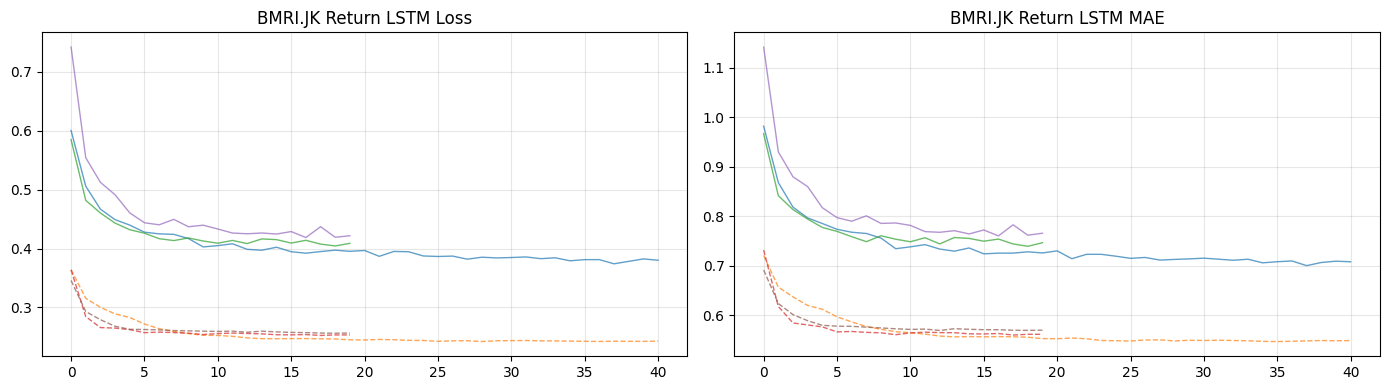

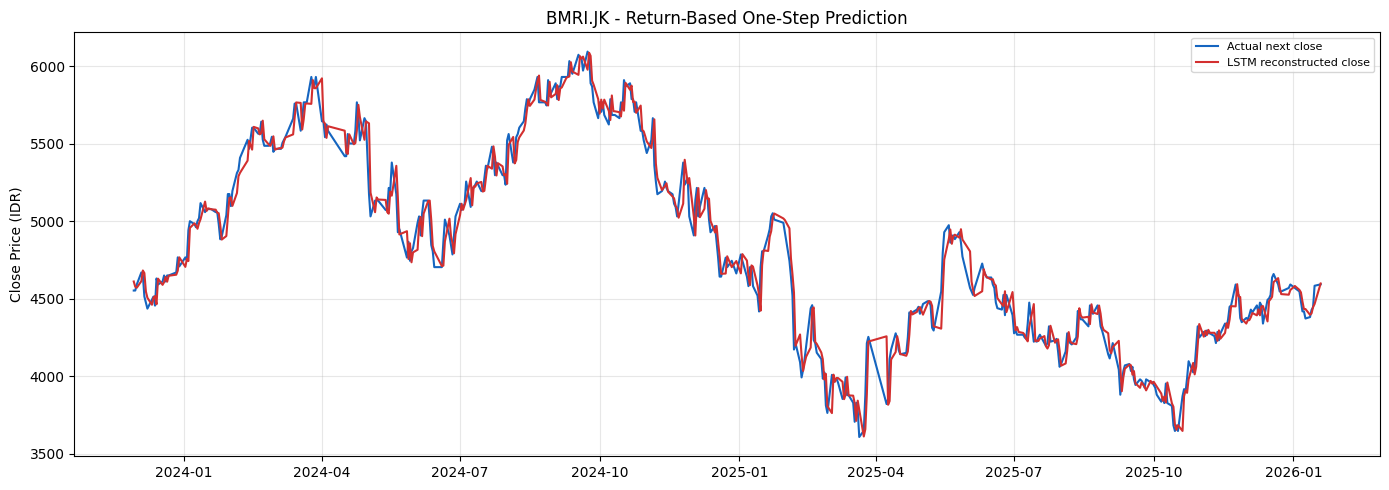

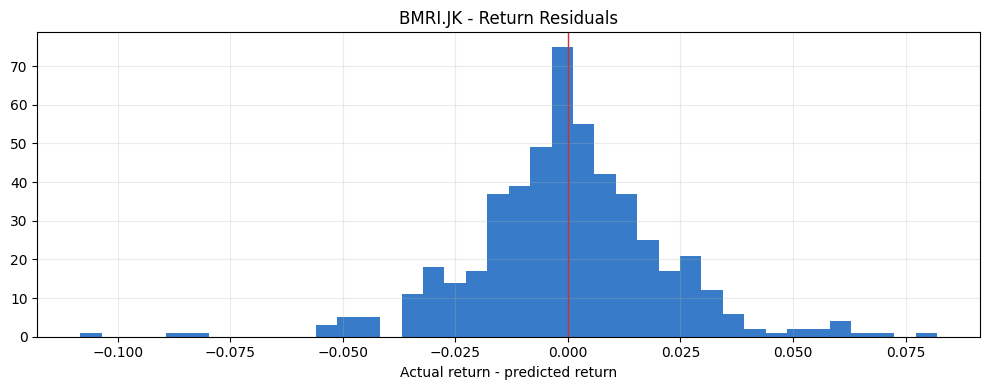

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for h in histories:
    axes[0].plot(h['loss'], alpha=0.7, lw=1); axes[0].plot(h['val_loss'], alpha=0.7, lw=1, linestyle='--')
    axes[1].plot(h['mae'], alpha=0.7, lw=1); axes[1].plot(h['val_mae'], alpha=0.7, lw=1, linestyle='--')
axes[0].set_title(f'{TICKER} Return LSTM Loss'); axes[1].set_title(f'{TICKER} Return LSTM MAE')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURE_DIR / f'return_{SAFE_TICKER}_training_curves.png', dpi=130, bbox_inches='tight'); plt.show()

test_pred_close = close_from_returns(test_base_close, test_lstm_pred)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, test_target_close, color=ACTUAL_COLOR, lw=1.5, label='Actual next close')
ax.plot(test_dates, test_pred_close, color=LSTM_COLOR, lw=1.5, label='LSTM reconstructed close')
ax.set_title(f'{TICKER} - Return-Based One-Step Prediction'); ax.set_ylabel('Close Price (IDR)')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURE_DIR / f'return_{SAFE_TICKER}_prediction_vs_actual.png', dpi=130, bbox_inches='tight'); plt.show()

residuals = y_test - test_lstm_pred
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals, bins=40, color=ACTUAL_COLOR, alpha=0.85); ax.axvline(0, color=LSTM_COLOR, lw=1)
ax.set_title(f'{TICKER} - Return Residuals'); ax.set_xlabel('Actual return - predicted return'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(FIGURE_DIR / f'return_{SAFE_TICKER}_residuals.png', dpi=130, bbox_inches='tight'); plt.show()


## Fit Status - Overfit / Good Fit / Underfit
Label ini dihitung dari gap error train vs test. Fokus utama pakai `Return_RMSE`, dengan `Price_RMSE` sebagai sanity check.


In [12]:
def classify_fit(metrics_table):
    rows = []
    for model_name in metrics_table['Model'].unique():
        model_metrics = metrics_table[metrics_table['Model'] == model_name]
        if set(model_metrics['Split']) < {'Train', 'Test'}:
            continue
        train = model_metrics[model_metrics['Split'] == 'Train'].iloc[0]
        test = model_metrics[model_metrics['Split'] == 'Test'].iloc[0]
        return_gap = test.Return_RMSE / max(train.Return_RMSE, 1e-12)
        price_gap = test.Price_RMSE / max(train.Price_RMSE, 1e-12)

        if return_gap <= 1.25 and price_gap <= 1.50:
            status = 'Good fit'
            reason = 'Train-test gap kecil.'
        elif return_gap <= 1.75 and price_gap <= 2.25:
            status = 'Mild overfit'
            reason = 'Test error lebih tinggi, tapi gap belum ekstrem.'
        elif return_gap > 1.75 or price_gap > 2.25:
            status = 'Overfit'
            reason = 'Train jauh lebih bagus daripada test.'
        else:
            status = 'Likely underfit'
            reason = 'Train dan test sama-sama lemah; perlu cek baseline.'

        rows.append({
            'Ticker': TICKER,
            'Model': model_name,
            'Train_Return_RMSE': train.Return_RMSE,
            'Test_Return_RMSE': test.Return_RMSE,
            'Return_Gap_Test/Train': return_gap,
            'Train_Price_RMSE': train.Price_RMSE,
            'Test_Price_RMSE': test.Price_RMSE,
            'Price_Gap_Test/Train': price_gap,
            'Fit_Status': status,
            'Reason': reason,
        })
    return pd.DataFrame(rows)

fit_status_df = classify_fit(metrics_df)
print('\nFIT STATUS / OVERFIT CHECK')
display(fit_status_df.style.format({
    'Train_Return_RMSE': '{:.5f}',
    'Test_Return_RMSE': '{:.5f}',
    'Return_Gap_Test/Train': '{:.2f}x',
    'Train_Price_RMSE': '{:,.2f}',
    'Test_Price_RMSE': '{:,.2f}',
    'Price_Gap_Test/Train': '{:.2f}x',
}))



FIT STATUS / OVERFIT CHECK


,Ticker,Model,Train_Return_RMSE,Test_Return_RMSE,Return_Gap_Test/Train,Train_Price_RMSE,Test_Price_RMSE,Price_Gap_Test/Train,Fit_Status,Reason
0,BMRI.JK,Naive_Zero_Return,0.02015,0.02089,1.04x,44.88,98.16,2.19x,Mild overfit,"Test error lebih tinggi, tapi gap belum ekstrem."
1,BMRI.JK,MA5_Return,0.02228,0.02285,1.03x,49.67,107.19,2.16x,Mild overfit,"Test error lebih tinggi, tapi gap belum ekstrem."
2,BMRI.JK,Ridge_Return,0.01601,0.02403,1.50x,37.86,113.28,2.99x,Overfit,Train jauh lebih bagus daripada test.
3,BMRI.JK,LSTM_Return_Ensemble,0.01968,0.02111,1.07x,44.13,99.10,2.25x,Mild overfit,"Test error lebih tinggi, tapi gap belum ekstrem."


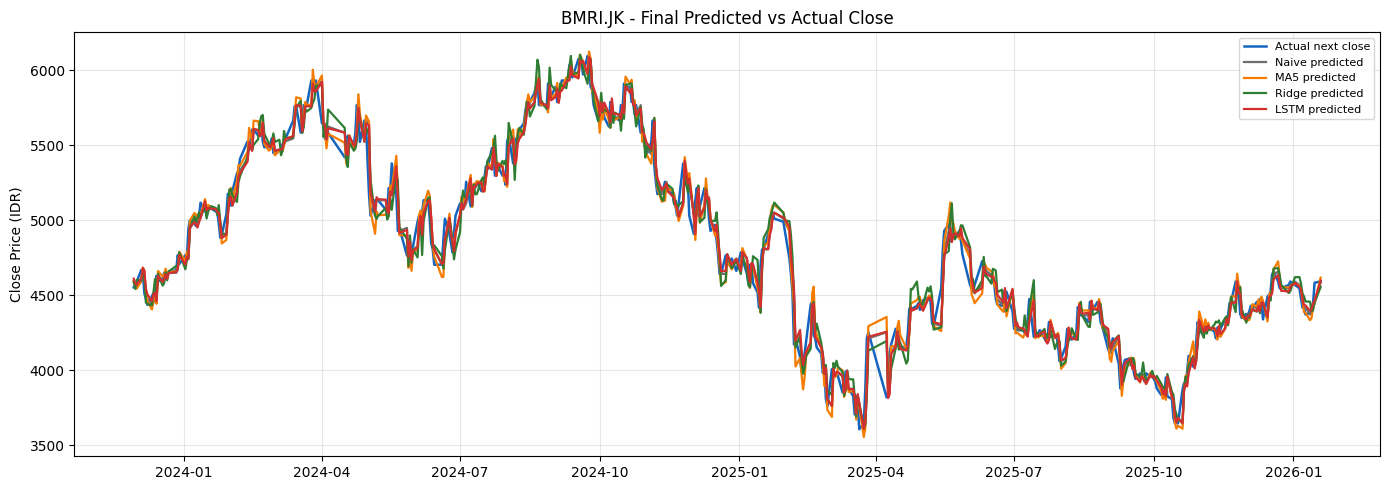

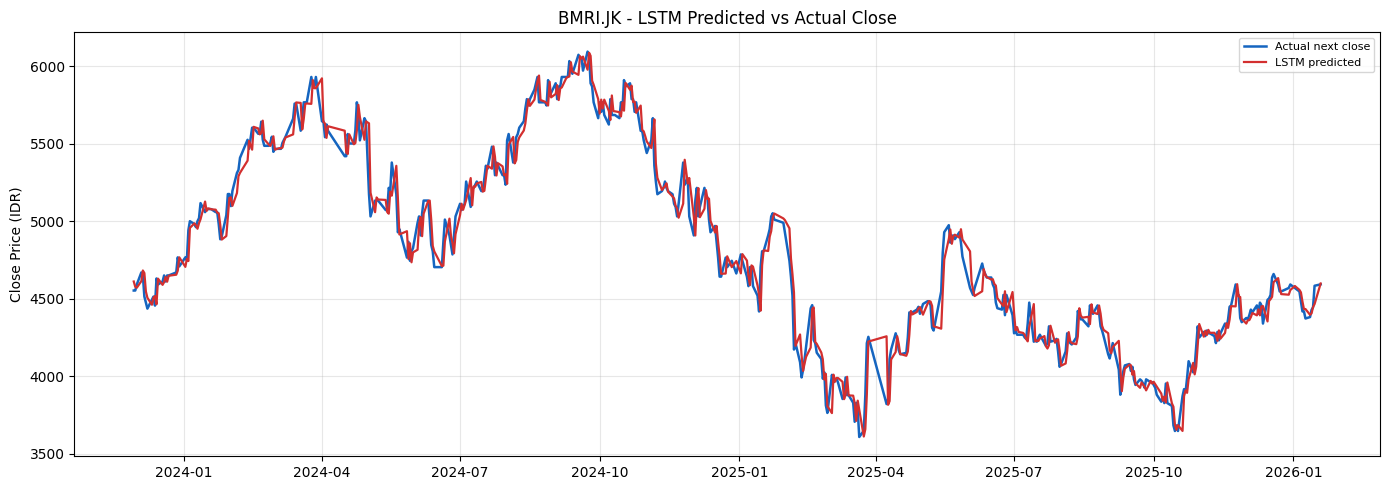

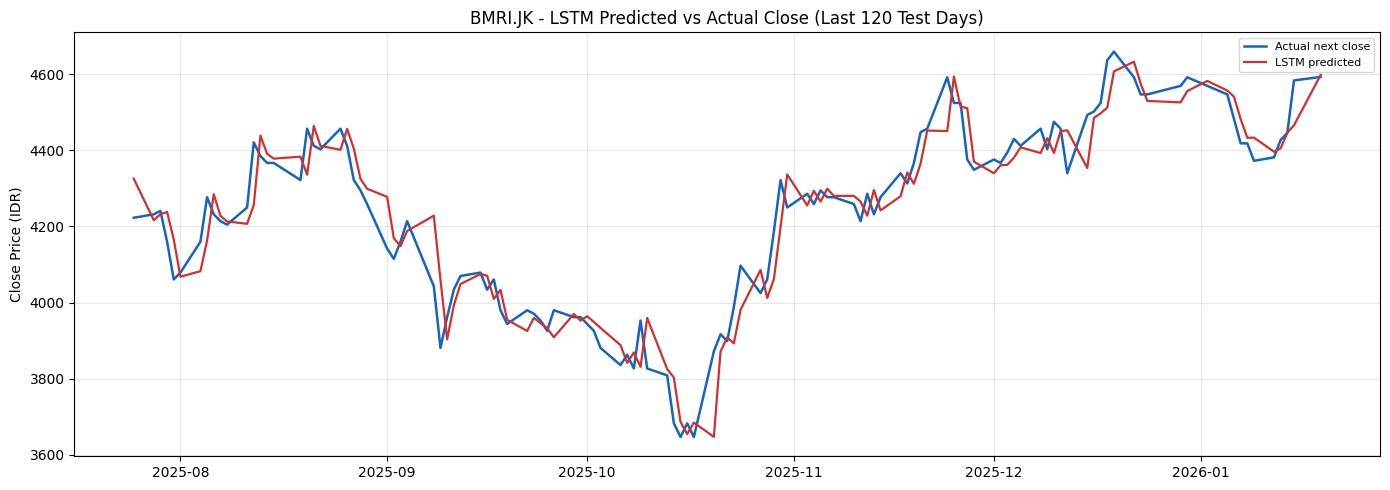

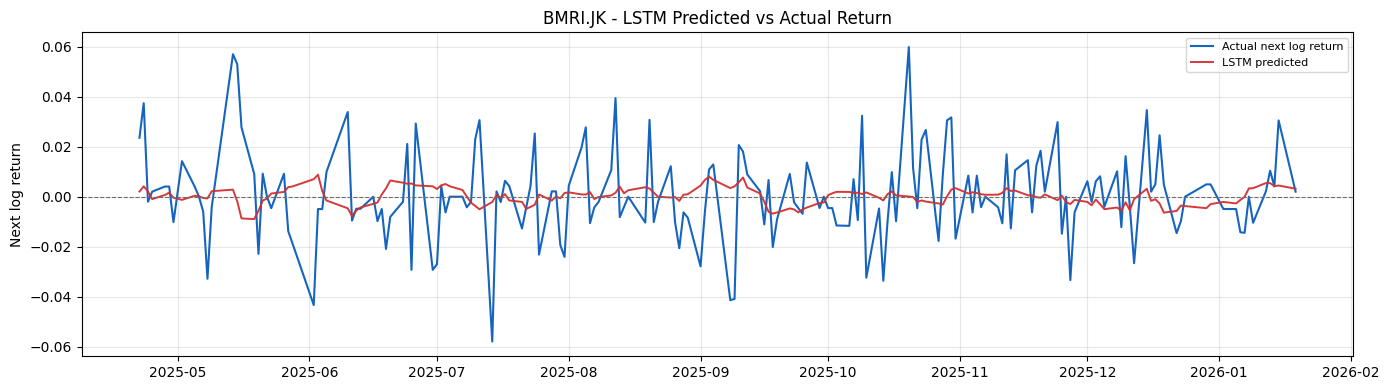

In [13]:
final_prediction_map = {
    'Naive': test_naive,
    'MA5': test_ma5,
    'Ridge': test_ridge_pred,
    'LSTM': test_lstm_pred,
}

plot_test_predictions(
    final_prediction_map,
    f'{TICKER} - Final Predicted vs Actual Close',
    f'return_{SAFE_TICKER}_final_prediction_vs_actual.png',
)

plot_test_predictions(
    {'LSTM': test_lstm_pred},
    f'{TICKER} - LSTM Predicted vs Actual Close',
    f'return_{SAFE_TICKER}_lstm_prediction_vs_actual.png',
)

plot_test_predictions(
    {'LSTM': test_lstm_pred},
    f'{TICKER} - LSTM Predicted vs Actual Close (Last 120 Test Days)',
    f'return_{SAFE_TICKER}_lstm_test_zoom.png',
    last_n=120,
)

plot_return_predictions(
    {'LSTM': test_lstm_pred},
    f'{TICKER} - LSTM Predicted vs Actual Return',
    f'return_{SAFE_TICKER}_lstm_return_prediction.png',
    last_n=180,
)


## 30-Day Forecast


,Date,Predicted_Log_Return,Predicted_Close
0,2026-01-16,0.003192,4598.387545
1,2026-01-19,0.001205,4603.930650
2,2026-01-20,-0.000096,4603.488431
3,2026-01-21,0.000112,4604.003117
4,2026-01-22,0.002538,4615.703687


,Date,Predicted_Log_Return,Predicted_Close
25,2026-02-20,0.012102,5668.932737
26,2026-02-23,0.012067,5737.753150
27,2026-02-24,0.012063,5807.389681
28,2026-02-25,0.012074,5877.930305
29,2026-02-26,0.012081,5949.370119


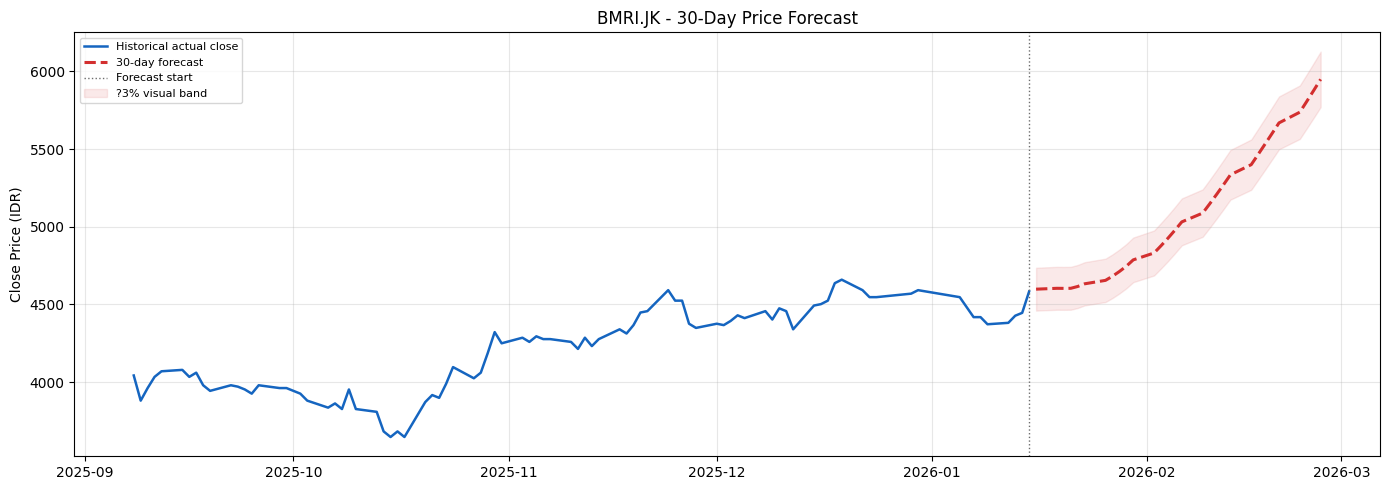

Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_model\BMRI_JK\return_BMRI_JK_forecast_30d.csv


In [14]:
FORECAST_DAYS = 30

# Forecast scenario: recursive one-step return prediction.
# Price/return/volatility features are updated from simulated closes.
# Non-price features that require unknown future data, such as volume/RSI/MACD, are carried forward.
def recursive_return_forecast(models, last_feature_window_raw, last_close, forecast_days=30):
    raw_window = last_feature_window_raw.copy()
    close_history = list(df['Close'].iloc[-80:].astype(float).values)
    pred_returns = []
    pred_closes = []
    current_close = float(last_close)

    for _ in range(forecast_days):
        scaled_window = feature_scaler.transform(raw_window).reshape(1, WINDOW_SIZE, len(feature_cols)).astype(np.float32)
        scaled_pred = np.mean([m.predict(scaled_window, verbose=0).ravel()[0] for m in models])
        pred_return = float(inverse_return([scaled_pred])[0])
        current_close = float(current_close * np.exp(pred_return))
        pred_returns.append(pred_return)
        pred_closes.append(current_close)

        close_history.append(current_close)
        returns = pd.Series(np.log(pd.Series(close_history) / pd.Series(close_history).shift(1))).dropna()
        prices = pd.Series(close_history)

        new_row = raw_window[-1].copy()
        feature_idx = {name: i for i, name in enumerate(feature_cols)}
        updates = {
            'Close_Log_Return_1': pred_return,
            'Daily_Return': np.exp(pred_return) - 1,
            'Return_3': prices.pct_change(3).iloc[-1],
            'Return_5': prices.pct_change(5).iloc[-1],
            'Return_10': prices.pct_change(10).iloc[-1],
            'Volatility_5': returns.rolling(5).std().iloc[-1],
            'Volatility_10': returns.rolling(10).std().iloc[-1],
            'Volatility_20': returns.rolling(20).std().iloc[-1],
        }
        for name, value in updates.items():
            if name in feature_idx and np.isfinite(value):
                new_row[feature_idx[name]] = value
        raw_window = np.vstack([raw_window[1:], new_row])

    future_dates = pd.bdate_range(start=pd.Timestamp(df['Date'].iloc[-1]) + pd.Timedelta(days=1), periods=forecast_days)
    return pd.DataFrame({
        'Date': future_dates,
        'Predicted_Log_Return': pred_returns,
        'Predicted_Close': pred_closes,
    })

forecast_30d = recursive_return_forecast(
    ensemble,
    X_raw[-1],
    df['Close'].iloc[-1],
    forecast_days=FORECAST_DAYS,
)

display(forecast_30d.head())
display(forecast_30d.tail())

last_n = 90
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'].iloc[-last_n:], df['Close'].iloc[-last_n:], color=ACTUAL_COLOR, lw=1.8, label='Historical actual close')
ax.plot(forecast_30d['Date'], forecast_30d['Predicted_Close'], color=LSTM_COLOR, lw=2.2, linestyle='--', label='30-day forecast')
ax.axvline(df['Date'].iloc[-1], color=NAIVE_COLOR, lw=1, linestyle=':', label='Forecast start')
ax.fill_between(
    forecast_30d['Date'],
    forecast_30d['Predicted_Close'] * 0.97,
    forecast_30d['Predicted_Close'] * 1.03,
    color=LSTM_COLOR,
    alpha=0.10,
    label='?3% visual band',
)
ax.set_title(f'{TICKER} - 30-Day Price Forecast')
ax.set_ylabel('Close Price (IDR)')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / f'return_{SAFE_TICKER}_forecast_30d.png', dpi=130, bbox_inches='tight')
plt.show()

forecast_path = RETURN_REPORT_DIR / f'return_{SAFE_TICKER}_forecast_30d.csv'
forecast_30d.to_csv(forecast_path, index=False)
print('Saved:', forecast_path)


## Export


In [16]:
one_step_signal = pd.DataFrame([{
    'Ticker': TICKER,
    'Signal_Date': pd.Timestamp(test_dates.iloc[-1]).date().isoformat(),
    'Base_Close': float(test_base_close[-1]),
    'Predicted_Next_Log_Return': float(test_lstm_pred[-1]),
    'Predicted_Next_Close': float(test_base_close[-1] * np.exp(test_lstm_pred[-1])),
    'Note': 'One-step signal only; recursive 30-day forecast intentionally disabled.',
}])
display(one_step_signal)

outputs = {
    f'return_{SAFE_TICKER}_metrics.csv': metrics_df,
    f'return_{SAFE_TICKER}_walk_forward.csv': walk_forward_df,
    f'return_{SAFE_TICKER}_acceptance.csv': acceptance_df,
    f'return_{SAFE_TICKER}_one_step_signal.csv': one_step_signal,
    f'return_{SAFE_TICKER}_fit_status.csv': fit_status_df,
}
for name, table in outputs.items():
    path = RETURN_REPORT_DIR / name
    table.to_csv(path, index=False)
    print('Saved:', path)


,Ticker,Signal_Date,Base_Close,Predicted_Next_Log_Return,Predicted_Next_Close,Note
0,BMRI.JK,2026-01-19,4583.733398,0.003192,4598.387207,One-step signal only; recursive 30-day forecas...


Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_model\BMRI_JK\return_BMRI_JK_metrics.csv
Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_model\BMRI_JK\return_BMRI_JK_walk_forward.csv
Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_model\BMRI_JK\return_BMRI_JK_acceptance.csv
Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_model\BMRI_JK\return_BMRI_JK_one_step_signal.csv
Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_model\BMRI_JK\return_BMRI_JK_fit_status.csv
